In [1]:
import warnings

# Suppress specific warning
warnings.filterwarnings("ignore", message="Graph is not fully connected, spectral embedding may not work as expected.", category=UserWarning)
# Suppress specific warning
warnings.filterwarnings("ignore", message="k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.", category=RuntimeWarning)
# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('../FUNCTIONS')
from methods import module_to_dict
from transitional_set import (construct_parent, construct_children, delete_children_connecting_edges, 
deleted_edges_to_nodes, merge_parent, delete_merged_nodes_connection, spectral_analysis, 
find_splitting_transitional_set, find_all_splitting_transitional_set, find_all_transitional_set)

In [3]:
!pwd
%cd Cell/Hotspot/
!pwd

/home/jovyan/work/transition_set
/home/jovyan/work/transition_set/Cell/Hotspot
/home/jovyan/work/transition_set/Cell/Hotspot


read stage modules

In [4]:
module_4S = module_to_dict("../../../parameter_tuning/Hotspot/Cell/module_4S_50.json")
module_I = module_to_dict("../../../parameter_tuning/Hotspot/Cell/module_I_50.json")
module_III = module_to_dict("../../../parameter_tuning/Hotspot/Cell/module_III_50.json")
module_IV = module_to_dict("../../../parameter_tuning/Hotspot/Cell/module_IV_50.json")

In [5]:
len(module_4S)

103

read pcc matrix

In [6]:
import pandas as pd
# import the PCC data
pcc_4S = pd.read_csv("../../../results/Cell/pcc_4S.csv", index_col=0)
pcc_I = pd.read_csv("../../../results/Cell/pcc_I.csv", index_col=0)
pcc_III = pd.read_csv("../../../results/Cell/pcc_III.csv", index_col=0)
pcc_IV = pd.read_csv("../../../results/Cell/pcc_IV.csv", index_col=0)
pcc_4S

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


In [7]:
pcc_4S.name = "pcc_4S"
pcc_I.name = "pcc_I"
pcc_III.name = "pcc_III"
pcc_IV.name = "pcc_IV"

In [8]:
from igraph import Graph
module_4S_vs_I_relation = Graph.Read_GraphML("module_4S_vs_I_relation.graphml")
module_4S_vs_III_relation = Graph.Read_GraphML("module_4S_vs_III_relation.graphml")
module_4S_vs_IV_relation = Graph.Read_GraphML("module_4S_vs_IV_relation.graphml")
module_I_vs_III_relation = Graph.Read_GraphML("module_I_vs_III_relation.graphml")
module_I_vs_IV_relation = Graph.Read_GraphML("module_I_vs_IV_relation.graphml")
module_III_vs_IV_relation = Graph.Read_GraphML("module_III_vs_IV_relation.graphml")

In [9]:
print(len(module_4S_vs_I_relation.vs))
print(len(module_4S_vs_III_relation.vs))
print(len(module_4S_vs_IV_relation.vs))
print(len(module_I_vs_III_relation.vs))
print(len(module_I_vs_IV_relation.vs))
print(len(module_III_vs_IV_relation.vs))

192
153
172
209
185
185


construct the parent graph (weighted undirected connected), with given pcc theshold

In [27]:
for i in module_I_vs_III_relation.vs["name"]:
    print(i)

module_I_24
module_III_5
module_III_26
module_I_8
module_III_6
module_III_2
module_III_12
module_III_22
module_I_3
module_III_0
module_III_8
module_III_23
module_III_15
module_I_1
module_III_21
module_I_5
module_III_14
module_III_10
module_III_104
module_III_24
module_III_52
module_III_153
module_III_99
module_III_44
module_III_88
module_I_2
module_III_4
module_III_42
module_III_69
module_III_17
module_III_16
module_I_4
module_III_3
module_III_65
module_III_32
module_I_0
module_III_7
module_III_1
module_III_56
module_I_6
module_I_14
module_III_76
module_I_10
module_I_49
module_I_22
module_I_32
module_I_28
module_I_27
module_III_38
module_I_16
module_III_50
module_I_19
module_III_67
module_III_29
module_I_31
module_I_117
module_III_62
module_I_59


In [33]:
module_I_vs_III_relation.neighbors("module_I_24")

[1, 2]

In [28]:
parent_graph = construct_parent(parent_name="module_I_24", stage_module=module_I, pcc_matrix=pcc_I, pcc_theshold=0.5)
print(parent_graph.summary())

IGRAPH UNW- 73 1075 -- 
+ attr: name (v), weight (e)


find overlapped children genes

In [29]:
children_overlapped_parts = construct_children(parent_name="module_I_24", parent_graph=parent_graph, relation_graph=module_I_vs_III_relation, stage_module=module_III)
print(children_overlapped_parts)

{'module_III_5': {'SMOC2', 'COLEC12', 'CYSLTR2', 'NR6A1', 'SCD5', 'CDC14B', 'DEGS2', 'MAGEE1', 'SLC35F3', 'FAM172A', 'CTSK', 'CMPK2', 'EPHA4', 'CXADR', 'ADI1', 'SERPING1', 'PLCB1', 'IFI27', 'CLDN11', 'PTPRE', 'SPTSSB'}, 'module_III_26': {'KLHL13', 'NIPAL2', 'RUNDC3A-AS1', 'SYT16', 'ARHGAP24'}}


In [31]:
for i in children_overlapped_parts:
    print(len(children_overlapped_parts[i]))

21
5


merge the parts of the parent overlapped with children into individual nodes

In [34]:
mg = merge_parent(parent_graph=parent_graph, children_overlapped_parts=children_overlapped_parts)
mg.summary()

'IGRAPH UNW- 49 563 -- \n+ attr: name (v), weight (e)'

In [35]:
print(mg.vs["name"])

['PDE8B', 'PPEF1', 'SLITRK6', 'IL20RB', 'PCOLCE', 'LRRC7', 'BTN3A1', 'TSPAN6', 'ATF7IP2', 'FAM110B', 'TMEM117', 'EMID1', 'PCDH10', 'HMGN5', 'MFNG', 'POPDC3', 'RIN1', 'CYTL1', 'MESP1', 'ACOT4', 'KIAA1217', 'MMP2', 'PLPP3', 'PFKFB3', 'GCHFR', 'MID1', 'EGR4', 'MCTP2', 'PTGER2', 'FAH', 'SEMA3B', 'SPRY1', 'DRAM1', 'LNX1', 'MIR222HG', 'PSME1', 'SERPINI1', 'TICAM1', 'ALDH3B1', 'TAC3', 'CYP27A1', 'HK2', 'ZNF837', 'BTN3A3', 'PDE4A', 'HSD17B1', 'EGR2', 'module_III_5', 'module_III_26']


In [39]:
print(sorted(mg.es["weight"], reverse=True)[:30])

[47, 17, 16, 15, 15, 14, 14, 13, 13, 12, 12, 12, 11, 11, 10, 9, 9, 9, 8, 8, 7, 7, 6, 5, 5, 5, 5, 4, 4, 4]


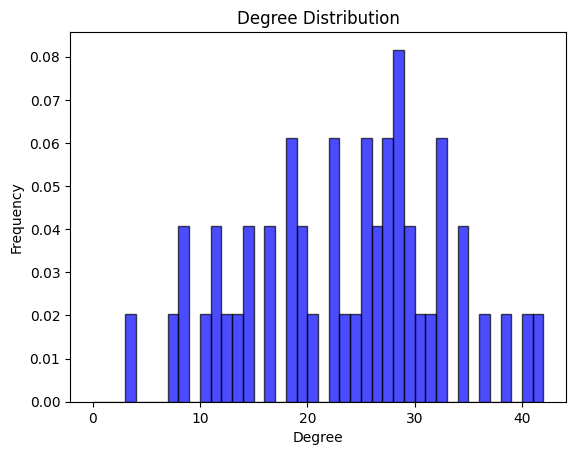

In [37]:
import matplotlib.pyplot as plt
# Get the degree sequence of the graph
degree_sequence = mg.degree()

# Plot the degree distribution
plt.hist(degree_sequence, bins=range(max(degree_sequence) + 2), density=True, alpha=0.7, color='b', edgecolor='black')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution')
plt.show()

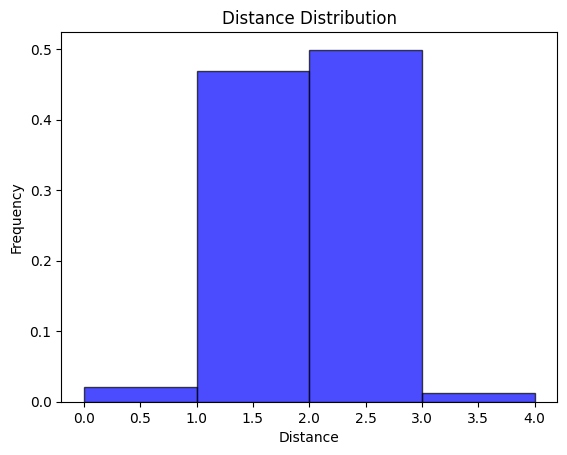

In [40]:
# Get all pairs of nodes' distances
distances = mg.distances()

# Flatten the distances matrix
all_distances = [distance for distances_row in distances for distance in distances_row if distance != float('inf')]

# Plot the distance distribution
plt.hist(all_distances, bins=range(int(max(all_distances)) + 2), density=True, alpha=0.7, color='b', edgecolor='black')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distance Distribution')
plt.show()

In [33]:
# from itertools import combinations

# # Find all neighboring vertices
# neighbors = module_I_vs_III_relation.neighbors("module_I_27")
# related = [module_I_vs_III_relation.vs.find(id)["name"] for id in neighbors]

# for i in related:
#     # List of nodes you want to connect
#     nodes_to_connect = set(module_I_27_graph.vs["name"]) & set(module_III[i])
    
#     # Add edges between all pairs of nodes
#     for pair in combinations(nodes_to_connect, 2):
#         # Check if the edge already exists
#         if not module_I_27_graph.are_connected(pair[0], pair[1]):
#             # If not, add the edge
#             module_I_27_graph.add_edge(pair[0], pair[1])

# # Now, 'g' is fully connected with all nodes in 'nodes_to_connect'
# print(module_I_27_graph.summary())

try spectral analysis clustering

In [34]:
# deleted_edge_list = list()
# for edge in g.es:
#     s = edge.source_vertex
#     t = edge.target_vertex
#     if s["color"] != t["color"]:
#         if s["name"].split("_")[0] == "module" and t["name"].split("_")[0] == "module":
#             for i in children_overlapped_parts[s["name"]]:
#                 for j in children_overlapped_parts[t["name"]]:
#                     if parent_graph.are_connected(i, j):
#                         deleted_edge_list.append((i, j))
#         # else:
#         #     continue
#         elif s["name"].split("_")[0] == "module":
#             for i in children_overlapped_parts[s["name"]]:
#                 if parent_graph.are_connected(t["name"], i):
#                     deleted_edge_list.append((t["name"], i))
#         elif t["name"].split("_")[0] == "module":
#             for i in children_overlapped_parts[t["name"]]:
#                 if parent_graph.are_connected(s["name"], i):
#                     deleted_edge_list.append((s["name"], i))
#         else:
#             deleted_edge_list.append((s["name"], t["name"]))
                
            
    

In [35]:
deleted_edge_list = delete_children_connecting_edges(parent_graph=parent_graph, children_overlapped_parts=children_overlapped_parts)
len(deleted_edge_list)

0

In [36]:
nodes = deleted_edges_to_nodes(deleted_edge_list=deleted_edge_list)
print(len(nodes))

0


In [37]:
dg = delete_merged_nodes_connection(merged_parent_graph=mg, children_overlapped_parts=children_overlapped_parts)
dg.summary()

'IGRAPH UNW- 11 10 -- \n+ attr: name (v), weight (e)'

In [38]:
labels = spectral_analysis(deleted_merged_nodes_connections_parent_graph=dg, n_clusters=3)
print(labels)

[1 2 2 2 2 0 0 1 1 2 2]


In [39]:
nodes = find_splitting_transitional_set(parent_name="module_I_22", first_stage_module=module_I, second_stage_module=module_III, relation_graph=module_I_vs_III_relation, pcc_matrix=pcc_I, pcc_theshold=0.7)
print(nodes[:10])

['MCTP2', 'MID1']


In [40]:
all_nodes_split = find_all_splitting_transitional_set(first_stage_module=module_I, second_stage_module=module_III, relation_graph=module_I_vs_III_relation, pcc_matrix=pcc_I, pcc_theshold=0.7)
print(len(all_nodes_split))

1840


In [41]:
all_nodes_merge = find_all_splitting_transitional_set(first_stage_module=module_III, second_stage_module=module_I, relation_graph=module_I_vs_III_relation, pcc_matrix=pcc_III, pcc_theshold=0.7)
print(len(all_nodes_merge))

674


final function works

In [10]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_4S, second_stage_module=module_I, relation_graph=module_4S_vs_I_relation, first_pcc_matrix=pcc_4S, second_pcc_matrix=pcc_I, pcc_theshold=0.5)
print(len(mutual_nodes))

790


In [11]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_4S, second_stage_module=module_III, relation_graph=module_4S_vs_III_relation, first_pcc_matrix=pcc_4S, second_pcc_matrix=pcc_III, pcc_theshold=0.5)
print(len(mutual_nodes))

467


In [12]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_4S, second_stage_module=module_IV, relation_graph=module_4S_vs_IV_relation, first_pcc_matrix=pcc_4S, second_pcc_matrix=pcc_IV, pcc_theshold=0.5)
print(len(mutual_nodes))

452


In [13]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_I, second_stage_module=module_III, relation_graph=module_I_vs_III_relation, first_pcc_matrix=pcc_I, second_pcc_matrix=pcc_III, pcc_theshold=0.5)
print(len(mutual_nodes))

839


In [14]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_I, second_stage_module=module_IV, relation_graph=module_I_vs_IV_relation, first_pcc_matrix=pcc_I, second_pcc_matrix=pcc_IV, pcc_theshold=0.5)
print(len(mutual_nodes))

851


In [15]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_III, second_stage_module=module_IV, relation_graph=module_III_vs_IV_relation, first_pcc_matrix=pcc_III, second_pcc_matrix=pcc_IV, pcc_theshold=0.5)
print(len(mutual_nodes))

683


In [16]:
print(list(mutual_nodes)[:10])

['ZNF785', 'HIST1H3J', 'KAT6A', 'POLQ', 'VPS28', 'DDC', 'LINC01176', 'ACAT2', 'JRKL', 'ARMCX1']
